In [4]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import heapq

In [5]:
# valor 0 es celda normal, valor 1 es celda bloqueada, valor 2 es celda salida, valor 3 es celda final
matriz = np.zeros((10,10), dtype=int)

completado=False
while not completado:
  matriz_x=int(input("Dime la posicion x de la celda a bloquear: "))
  matriz_y=int(input("Dime la posicion y de la celda a bloquear: "))
  matriz[matriz_x,matriz_y]=1
  completo=input("Quieres continuar? (S/N)")
  if completo=="N":
    completado=True

origen_x=int(input("Dime la posicion x de la celda del salida: "))
origen_y=int(input("Dime la posicion y de la celda del salida: "))
salida=(origen_x,origen_y)
matriz[origen_x,origen_y]=2

meta_x=int(input("Dime la posicion x de la celda del meta: "))
meta_y=int(input("Dime la posicion y de la celda del meta: "))
meta=(meta_x,meta_y)
matriz[meta_x,meta_y]=3

Dime la posicion x de la celda a bloquear: 1
Dime la posicion y de la celda a bloquear: 1
Quieres continuar? (S/N)N
Dime la posicion x de la celda del salida: 0
Dime la posicion y de la celda del salida: 0
Dime la posicion x de la celda del meta: 2
Dime la posicion y de la celda del meta: 3


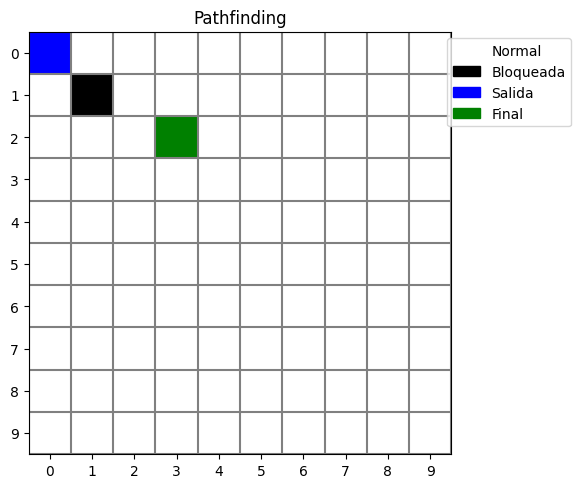

In [6]:
colores=["white","black","blue","green"]
cmap=ListedColormap(colores)
norm=BoundaryNorm([0,1,2,3,4],cmap.N)

plt.figure(figsize=(6,6))
plt.imshow(matriz,cmap=cmap,norm=norm,origin="upper")
# Cuadrícula en bordes de celdas
plt.gca().set_xticks(np.arange(-0.5,10,1),minor=True)
plt.gca().set_yticks(np.arange(-0.5,10,1),minor=True)
plt.grid(which="minor",color="gray",linestyle="-",linewidth=1.5)
plt.tick_params(which="minor",bottom=False,left=False)
plt.xticks(np.arange(0,10,1))
plt.yticks(np.arange(0,10,1))

# Leyenda
leyenda=[
    #ec=gray es para que se vea el borde de las casillas blancas, sino como el fondo es blanco no se ve el color
    Patch(color="white",label="Normal",ec="gray"),
    Patch(color="black",label="Bloqueada"),
    Patch(color="blue",label="Salida"),
    Patch(color="green",label="Final"),
]
#Con el loc upper right se pone la leyenda arriba derecha
plt.legend(handles=leyenda,loc="upper right",bbox_to_anchor=(1.3,1))

plt.title("Pathfinding")
plt.tight_layout()
plt.show()

In [7]:
#Funcion octile euclidiana
def octile(salida, meta):
  dx=abs(salida[0]-meta[0])
  dy=abs(salida[1]-meta[1])
  f=np.sqrt(2)-1
  return max(dx,dy)+f*min(dx,dy)

print(octile(salida, meta))


3.8284271247461903


In [8]:
def astar(matriz, salida, meta):
  heap=[(octile(salida, meta),salida)]
  came_from = {salida: None}
  g_cost = {salida: 0}

  #Para el bucle tuve que usar IA para crearlo, tenia una idea de lo que hacer pero no en como hacerlo
  while heap:
    _, actual = heapq.heappop(heap)

    if actual == meta:
      camino = []
      while actual is not None:
        camino.append(actual)
        actual = came_from[actual]
      return camino[::-1]

    fila, col = actual
    for df in [-1, 0, 1]:
      for dc in [-1, 0, 1]:
        if df == 0 and dc == 0:
          continue

        vecino = (fila + df, col + dc)
        vf, vc = vecino

        if not (0 <= vf < len(matriz) and 0 <= vc < len(matriz[0])):
          continue
        if matriz[vf][vc] == 1:
          continue

        coste = np.sqrt(2) if df != 0 and dc != 0 else 1
        nuevo_g = g_cost[actual] + coste

        if nuevo_g < g_cost.get(vecino, float("inf")):
          g_cost[vecino] = nuevo_g
          f = nuevo_g + octile(vecino, meta)
          heapq.heappush(heap, (f, vecino))
          came_from[vecino] = actual
  return None

In [9]:
ruta=astar(matriz,salida,meta)

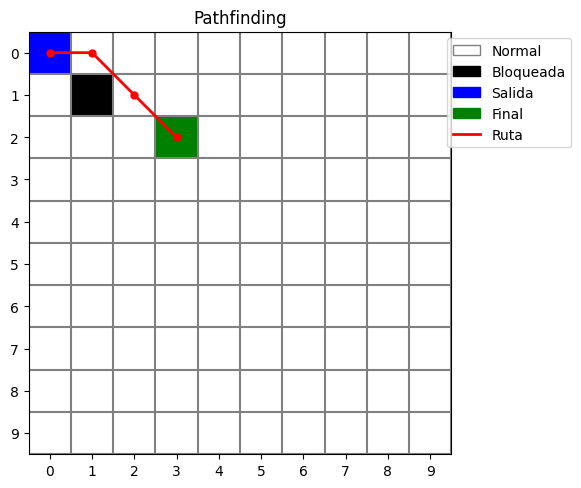

In [10]:
colores=["white","black","blue","green"]
cmap=ListedColormap(colores)
norm=BoundaryNorm([0,1,2,3,4],cmap.N)
plt.figure(figsize=(6,6))
plt.imshow(matriz,cmap=cmap,norm=norm,origin="upper")
#La linea de la ruta
filas = [c[0] for c in ruta]
cols = [c[1] for c in ruta]
plt.plot(cols,filas,color="red",linewidth=2,marker="o",markersize=5)

plt.gca().set_xticks(np.arange(-0.5,10,1),minor=True)
plt.gca().set_yticks(np.arange(-0.5,10,1),minor=True)
plt.grid(which="minor",color="gray",linestyle="-",linewidth=1.5)
plt.tick_params(which="minor",bottom=False,left=False)
plt.xticks(np.arange(0,10,1))
plt.yticks(np.arange(0,10,1))

#Leyenda
leyenda=[
    Patch(color="white",label="Normal",ec="gray"),
    Patch(color="black",label="Bloqueada"),
    Patch(color="blue",label="Salida"),
    Patch(color="green",label="Final"),
    #Para incluir en la leyenda la linea de la ruta
    matplotlib.lines.Line2D([0],[0],color="red",linewidth=2,label="Ruta")
]
#Con loc upper right pongo la leyenda arriba derecha para que no moleste
plt.legend(handles=leyenda,loc="upper right",bbox_to_anchor=(1.3,1))

plt.title("Pathfinding")
plt.tight_layout()
plt.show()